# Finding Similar Items
arXiv dataset, Jaccard similarity, shingling + minhash + LSH

## Download Data

In [ ]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations

np.random.seed(42)

#with open('creds.json') as f:
#    creds = json.load(f)

# os.environ['KAGGLE_USERNAME'] = creds['username']
# os.environ['KAGGLE_KEY'] = creds['key']

os.environ['KAGGLE_USERNAME'] = 'xxxxx'
os.environ['KAGGLE_KEY'] = 'xx'

# !pip install -q kaggle
# !kaggle datasets download -d Cornell-University/arxiv
# !unzip -q arxiv.zip

In [ ]:
#!wc -l arxiv-metadata-oai-snapshot.json
# rouglhy 3m articles

 2975294 arxiv-metadata-oai-snapshot.json


In [5]:
DATA_PATH = 'arxiv-metadata-oai-snapshot.json'
MAX_PAPERS = 50_000

# the full dataset has ~3M papers — I cap at 50k to keep runtimes reasonable
# while still being large enough that brute force is clearly impractical.
# setting to None allows to run on everything

In [38]:
def load_arxiv(path, max_papers=None):
    records = []
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            if max_papers and i >= max_papers:
                break
            p = json.loads(line)
            records.append({
                'id': p['id'],
                'title': p['title'].strip().replace('\n', ' '),
                'abstract': p['abstract'].strip().replace('\n', ' '),
                'categories': p['categories'],
            })
    return pd.DataFrame(records)

df = load_arxiv(DATA_PATH, MAX_PAPERS)

small = df.sample(100, random_state=42).reset_index(drop=True)
med   = df.sample(min(10_000, len(df)), random_state=42).reset_index(drop=True)

In [7]:
df.head(3)

,id,title,abstract,categories
0,0704.0001,Calculation of prompt diphoton production cros...,A fully differential calculation in perturbati...,hep-ph
1,0704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-pe...",math.CO cs.CG
2,0704.0003,The evolution of the Earth-Moon system based o...,The evolution of Earth-Moon system is describe...,physics.gen-ph


In [7]:
df['abstract'].str.len().describe()

count    50000.000000
mean       789.889200
std        402.010348
min         17.000000
25%        496.000000
50%        716.500000
75%       1027.000000
max       2861.000000
Name: abstract, dtype: float64

# Algorithms

## 1. Jaccard similarity

$$\text{Jaccard}(S, T) = \frac{|S \cap T|}{|S \cup T|}$$

I start with the simplest possible representation — each abstract as a bag of words — just to get a feel for the data before moving to something smarter.

In [46]:
def jaccard(a, b):
    if not a and not b:
        return 1.0
    inter = len(a & b)
    return inter / (len(a) + len(b) - inter)


word_sets = [set(doc.lower().split()) for doc in small['abstract']]

n = len(word_sets)
sim = np.zeros((n, n))

t0 = time.time()
for i in range(n):
    for j in range(i, n):
        s = jaccard(word_sets[i], word_sets[j])
        sim[i, j] = sim[j, i] = s

print(f'{n*(n-1)//2} pairs in {time.time()-t0:.3f}s')

4950 pairs in 0.015s


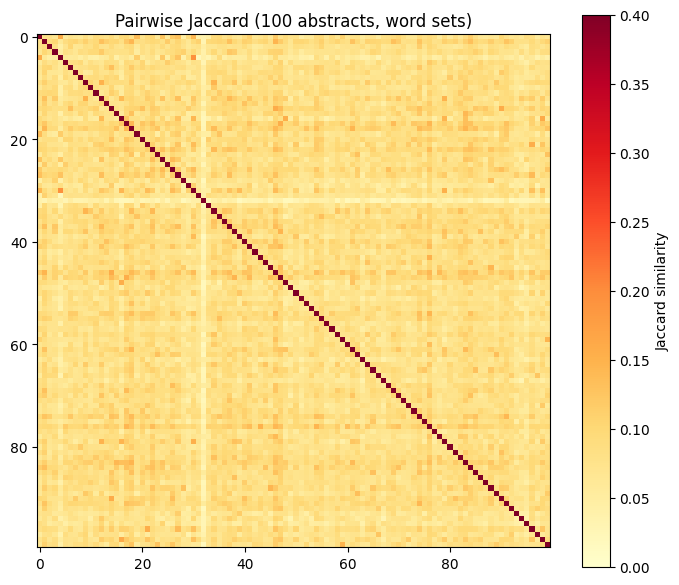

In [24]:
plt.figure(figsize=(7, 6))
plt.imshow(sim, cmap='YlOrRd', vmin=0, vmax=0.4)
plt.colorbar(label='Jaccard similarity')
plt.title(f'Pairwise Jaccard ({n} abstracts, word sets)')
plt.tight_layout()
plt.show()

In [47]:
pairs = sorted(
    [(i, j, sim[i, j]) for i in range(n) for j in range(i+1, n)],
    key=lambda x: x[2], reverse=True
)

for rank, (i, j, s) in enumerate(pairs[:10], 1):
    print(f'{rank:2}. sim={s:.3f}')
    print(f'    [{small.iloc[i]["categories"]}] {small.iloc[i]["title"][:70]}')
    print(f'    [{small.iloc[j]["categories"]}] {small.iloc[j]["title"][:70]}')
    print()

 1. sim=0.195
    [math.RT math.AG math.RA] Symplectic reflection algebras
    [math.RT math.AG] Representations of quivers, their generalizations and invariants

 2. sim=0.159
    [math.CA] Functions of q-positive type
    [math.CA] Uniform estimates for cubic oscillatory integrals

 3. sim=0.157
    [gr-qc] Quantum cosmology with varying speed of light and Bohmian trajectories
    [math.FA] Integrable operators and squares of Hankel Matrices

 4. sim=0.157
    [hep-lat hep-ph] Recent lattice results on finite temerature and density QCD, part II
    [math.RT math.AG math.RA] Symplectic reflection algebras

 5. sim=0.157
    [gr-qc] Quantum cosmology with varying speed of light and Bohmian trajectories
    [quant-ph] The meeting problem in the quantum random walk

 6. sim=0.156
    [math.CA] Functions of q-positive type
    [math.AG math.GT] A note on local trigonal fibrations

 7. sim=0.155
    [math-ph math.MP] Poisson brackets in Hydrodynamics
    [math.CO] Quasi-period collapse and

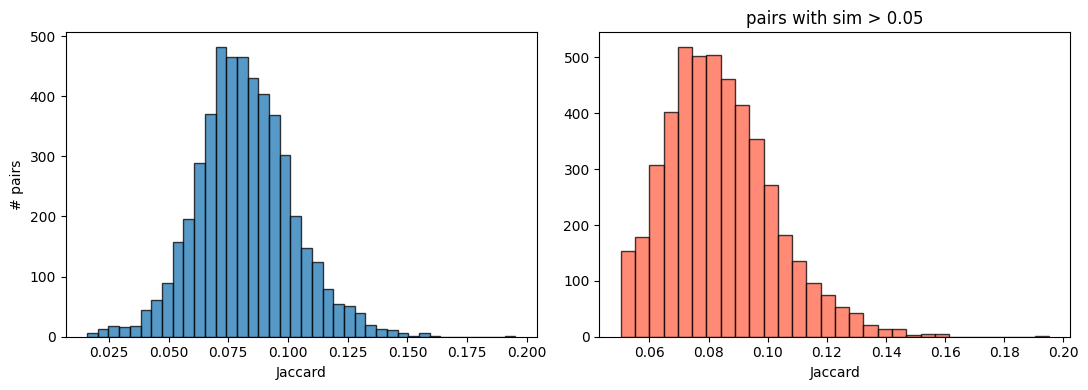

pairs >= 0.1: 839
pairs >= 0.2: 0
pairs >= 0.3: 0


In [48]:
off_diag = sim[np.triu_indices(n, k=1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(off_diag, bins=40, edgecolor='k', alpha=0.75)
ax1.set_xlabel('Jaccard')
ax1.set_ylabel('# pairs')

ax2.hist(off_diag[off_diag > 0.05], bins=30, edgecolor='k', alpha=0.75, color='tomato')
ax2.set_xlabel('Jaccard')
ax2.set_title('pairs with sim > 0.05')

plt.tight_layout()
plt.show()

for t in [0.1, 0.2, 0.3]:
    print(f'pairs >= {t}: {(off_diag >= t).sum()}')

In [49]:
# each comparison takes ~1µs, so the total time grows quadratically — at 50k docs
# we're already looking at ~20 minutes just to compute similarities, and at 1M it's 6 days
for n_docs in [100, 1_000, 10_000, 50_000, 1_000_000]:
    n_pairs = n_docs * (n_docs - 1) // 2
    secs = n_pairs * 1e-6
    if secs < 60:
        t_str = f'{secs:.0f}s'
    elif secs < 3600:
        t_str = f'{secs/60:.1f} min'
    elif secs < 86400:
        t_str = f'{secs/3600:.1f} hr'
    else:
        t_str = f'{secs/86400:.1f} days'
    print(f'n={n_docs:>10,}  pairs={n_pairs:>16,}  ~{t_str}')

n=       100  pairs=           4,950  ~0s
n=     1,000  pairs=         499,500  ~0s
n=    10,000  pairs=      49,995,000  ~50s
n=    50,000  pairs=   1,249,975,000  ~20.8 min
n= 1,000,000  pairs= 499,999,500,000  ~5.8 days


## 2. Shingling

Word sets throw away word order and get confused by paraphrasing. I instead represent each abstract as a set of overlapping character substrings of length $k$. Two documents that share phrases will share many of these substrings, even if the words are shuffled around.

I store hashed shingles (32-bit integers) instead of raw strings — same similarity values, much less memory.

In [50]:
def shingle(text, k):
    text = ' '.join(text.lower().split())
    return {text[i:i+k] for i in range(len(text) - k + 1)}


def shingle_hashed(text, k):
    text = ' '.join(text.lower().split())
    return {hash(text[i:i+k]) & 0xffffffff for i in range(len(text) - k + 1)}

In [51]:
for k in [3, 5, 7, 9]:
    sizes = [len(shingle(doc, k)) for doc in small['abstract']]
    print(f'k={k}:  avg={np.mean(sizes):.0f}  min={min(sizes)}  max={max(sizes)}')

k=3:  avg=438  min=135  max=769
k=5:  avg=607  min=161  max=1225
k=7:  avg=672  min=174  max=1444
k=9:  avg=703  min=179  max=1569


In [52]:
K = 9
shingles_small = [shingle_hashed(doc, K) for doc in small['abstract']]

print(f'avg shingle set size: {np.mean([len(s) for s in shingles_small]):.0f}\n')

# word sets vs shingle sets
print(f'{"pair":<8} {"word sim":>10} {"shingle sim":>12}')
for i, j in [(0,1), (0,2), (1,2), (3,7), (5,15)]:
    ws = jaccard(word_sets[i], word_sets[j])
    ss = jaccard(shingles_small[i], shingles_small[j])
    print(f'({i},{j})    {ws:>10.4f} {ss:>12.4f}')

avg shingle set size: 703

pair       word sim  shingle sim
(0,1)        0.0755       0.0011
(0,2)        0.0753       0.0010
(1,2)        0.0882       0.0000
(3,7)        0.0655       0.0043
(5,15)        0.0818       0.0061


In [53]:
# I want to make sure hashing doesn't change similarity values
raw = [shingle(doc, K) for doc in small['abstract'][:5]]
hsh = [shingle_hashed(doc, K) for doc in small['abstract'][:5]]

for i, j in [(0,1), (1,2), (2,3)]:
    print(f'({i},{j})  raw={jaccard(raw[i], raw[j]):.4f}  hashed={jaccard(hsh[i], hsh[j]):.4f}')

(0,1)  raw=0.0011  hashed=0.0011
(1,2)  raw=0.0000  hashed=0.0000
(2,3)  raw=0.0091  hashed=0.0091


## 3. MinHashing

I compress each shingle set into a short vector of integers — a signature. The core property is that for a random row permutation $h$:

$$P[h(S) = h(T)] = \text{Jaccard}(S, T)$$

So the fraction of matching entries across many independent hash functions gives an unbiased estimate of the true Jaccard similarity. I can't actually permute billions of rows, so I simulate it with linear hash functions:

$$h_i(r) = (a_i \cdot r + b_i) \bmod p$$

and take the minimum hash value seen across all elements in a set.

In [54]:
def _hash_params(n, p=2**31 - 1):
    a = np.random.randint(1, p, size=n)
    b = np.random.randint(0, p, size=n)
    return a, b, p


def minhash(sets, n_hashes=100):
    elem_idx = {}
    for s in sets:
        for e in s:
            if e not in elem_idx:
                elem_idx[e] = len(elem_idx)

    a, b, p = _hash_params(n_hashes)
    sig = np.full((n_hashes, len(sets)), np.iinfo(np.int64).max, dtype=np.int64)

    for col, s in enumerate(sets):
        for e in s:
            r = elem_idx[e]
            hvals = (a * r + b) % p
            np.minimum(sig[:, col], hvals, out=sig[:, col])

    return sig


def sig_sim(sig, i, j):
    return np.mean(sig[:, i] == sig[:, j])

In [55]:
t0 = time.time()
sig_small = minhash(shingles_small, n_hashes=100)
print(f'shape: {sig_small.shape}  ({time.time()-t0:.2f}s)')

shape: (100, 100)  (0.16s)


In [56]:
print(f'{"pair":<8} {"true":>12} {"estimate":>12}')
for i, j in [(0,1), (0,2), (1,2), (3,7), (5,15), (10,20)]:
    true = jaccard(shingles_small[i], shingles_small[j])
    est  = sig_sim(sig_small, i, j)
    print(f'({i},{j})    {true:>12.4f} {est:>12.4f}')

pair             true     estimate
(0,1)          0.0011       0.0000
(0,2)          0.0010       0.0000
(1,2)          0.0000       0.0000
(3,7)          0.0043       0.0000
(5,15)          0.0061       0.0100
(10,20)          0.0084       0.0000


In [59]:
# There I want to see how many hashes I actually need before estimates stabilize
test_sets = shingles_small[:20]
test_pairs = list(combinations(range(20), 2))
true_sims = {(i, j): jaccard(test_sets[i], test_sets[j]) for i, j in test_pairs}

for nh in [10, 25, 50, 100, 200]:
    sig_t = minhash(test_sets, n_hashes=nh)
    errs  = [abs(true_sims[(i,j)] - sig_sim(sig_t, i, j)) for i,j in test_pairs]
    print(f'n_hashes={nh:>4}  MAE={np.mean(errs):.4f}')

n_hashes=  10  MAE=0.0250
n_hashes=  25  MAE=0.0074
n_hashes=  50  MAE=0.0057
n_hashes= 100  MAE=0.0046
n_hashes= 200  MAE=0.0036


## 4. Locality-Sensitive Hashing

Even with signatures, comparing all pairs is too slow. The idea: I split the signature matrix into $b$ bands of $r$ rows each. Two documents become candidates if their signature vectors match exactly in at least one band. The probability of that happening is:

$$P(\text{candidate} \mid s) = 1 - (1 - s^r)^b$$

This is an S-curve — it rises sharply around a threshold $t \approx (1/b)^{1/r}$. Below that threshold most pairs are ignored; above it most pairs get caught. I only check candidates for true similarity.

In [60]:
def s_curve(s, b, r):
    return 1 - (1 - s**r)**b

def lsh_threshold(b, r):
    return (1/b) ** (1/r)


configs = [(10, 10), (20, 5), (25, 4), (50, 2)]
print(f'{"b":>5} {"r":>5}  {"n_hashes":>9}  {"threshold":>10}')
for b, r in configs:
    print(f'{b:>5} {r:>5}  {b*r:>9}  {lsh_threshold(b,r):>10.3f}')

    b     r   n_hashes   threshold
   10    10        100       0.794
   20     5        100       0.549
   25     4        100       0.447
   50     2        100       0.141


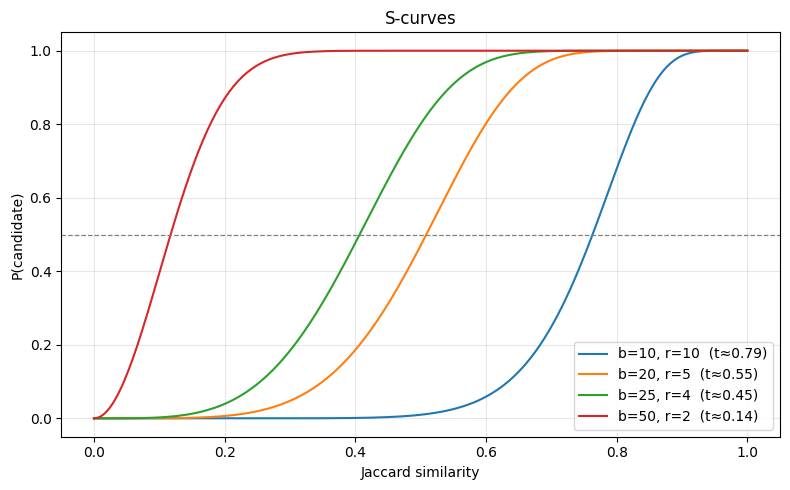

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.linspace(0, 1, 300)

for b, r in configs:
    ax.plot(x, s_curve(x, b, r), label=f'b={b}, r={r}  (t≈{lsh_threshold(b,r):.2f})')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.9)
ax.set_xlabel('Jaccard similarity')
ax.set_ylabel('P(candidate)')
ax.set_title('S-curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
def lsh_candidates(sig, b, r):
    _, n_docs = sig.shape
    candidates = set()

    for band in range(b):
        lo = band * r
        buckets = {}
        for doc in range(n_docs):
            key = tuple(sig[lo:lo+r, doc])
            if key in buckets:
                for other in buckets[key]:
                    candidates.add((min(doc, other), max(doc, other)))
                buckets[key].append(doc)
            else:
                buckets[key] = [doc]

    return candidates

In [64]:
print('for 10k docs:')

t0 = time.time()
shingles_med = [shingle_hashed(doc, K) for doc in med['abstract']]
print(f'  shingling: {time.time()-t0:.1f}s')

t0 = time.time()
sig_med = minhash(shingles_med, n_hashes=100)
print(f'  minhash:   {time.time()-t0:.1f}s')

B, R = 25, 4
t0 = time.time()
cands = lsh_candidates(sig_med, B, R)
print(f'  LSH:       {time.time()-t0:.1f}s')

n_med = len(shingles_med)
total = n_med * (n_med - 1) // 2
print(f'\n{len(cands):,} candidates / {total:,} total ({len(cands)/total*100:.2f}%)')

for 10k docs:
  shingling: 1.2s
  minhash:   16.3s
  LSH:       0.9s

138 candidates / 49,995,000 total (0.00%)


In [65]:
# I can only brute-force a small slice, so I measure recall there
EVAL_N = 300
SIM_THR = 0.3

truly_similar = set()
for i, j in combinations(range(EVAL_N), 2):
    if jaccard(shingles_med[i], shingles_med[j]) >= SIM_THR:
        truly_similar.add((i, j))

slice_cands = cands & set(combinations(range(EVAL_N), 2))
caught = truly_similar & slice_cands

print(f'truly similar (thr={SIM_THR}): {len(truly_similar)}')
print(f'candidates in slice: {len(slice_cands)}')
print(f'caught: {len(caught)}')
if truly_similar:
    print(f'recall:    {len(caught)/len(truly_similar):.1%}')
if slice_cands:
    print(f'precision: {len(caught)/len(slice_cands):.1%}')

truly similar (thr=0.3): 0
candidates in slice: 0
caught: 0


In [66]:
results = []
for i, j in cands:
    est = sig_sim(sig_med, i, j)
    if est >= SIM_THR:
        results.append((i, j, est))

results.sort(key=lambda x: x[2], reverse=True)
print(f'{len(results)} pairs with est >= {SIM_THR}\n')

for rank, (i, j, est) in enumerate(results[:15], 1):
    true = jaccard(shingles_med[i], shingles_med[j])
    print(f'{rank:2}. est={est:.3f}  true={true:.3f}  '
          f'[{med.iloc[i]["categories"]}] vs [{med.iloc[j]["categories"]}]')
    print(f'    {med.iloc[i]["title"][:75]}')
    print(f'    {med.iloc[j]["title"][:75]}')

116 pairs with est >= 0.3

 1. est=1.000  true=1.000  [math-ph math.MP] vs [nlin.CD]
    Flow of a non-Newtonian fluids on a flat plate: II. heat transfer
    A comment on "Computational periodicity as observed in a simple system,"   
 2. est=1.000  true=1.000  [astro-ph] vs [astro-ph]
    Diffuse Gamma-Rays Produced in Cosmic-Ray Interactions and the TeV-band   S
    Gamma-Rays Produced in Cosmic-Ray Interactions and the TeV-band Spectrum   
 3. est=1.000  true=1.000  [math.DG] vs [cond-mat.other physics.optics quant-ph]
    A new proof of the Beez-Cartan theorem
    Laser Pulse Amplification with Bose-Einstein Condensates
 4. est=1.000  true=1.000  [cs.IT math.IT] vs [math.QA math.CO]
    Collaborative Gain in Resource Sharing Communication Networks
    On dual quadri-algebras
 5. est=1.000  true=1.000  [math.HO] vs [math.HO]
    Some series and integrals involving the Riemann zeta function, binomial   c
    Some series and integrals involving the Riemann zeta function, binomial   c


## 5. Distance measures

Jaccard distance $d(S, T) = 1 - \text{Jaccard}(S, T)$ satisfies all metric axioms. I also look at cosine distance on TF vectors and $L_p$ norms — useful when documents are represented as vectors rather than sets.

In [67]:
def cosine_dist(x, y):
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    denom = np.linalg.norm(x) * np.linalg.norm(y)
    if denom == 0:
        return 1.0
    return 1.0 - np.dot(x, y) / denom


def lp_dist(x, y, p=2):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if p == np.inf:
        return float(np.max(np.abs(x - y)))
    return float(np.sum(np.abs(x - y)**p) ** (1/p))


def edit_dist(s, t):
    m, n = len(s), len(t)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s[i-1] == t[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return m + n - 2 * dp[m][n]

In [68]:
def tf_matrix(docs):
    vocab = {}
    for doc in docs:
        for w in doc.lower().split():
            if w not in vocab:
                vocab[w] = len(vocab)
    vecs = np.zeros((len(docs), len(vocab)))
    for i, doc in enumerate(docs):
        for w, cnt in Counter(doc.lower().split()).items():
            vecs[i, vocab[w]] = cnt
    return vecs


sample_docs = [med.iloc[i]['abstract'] for i in range(20)]
sample_shingles = shingles_med[:20]
tf = tf_matrix(sample_docs)

print(f'{"pair":<8} {"jaccard":>10} {"jac_dist":>10} {"cosine°":>9} {"L2":>8} {"L1":>8}')
for i, j in [(0,1), (0,2), (1,2), (3,7), (5,10)]:
    jac = jaccard(sample_shingles[i], sample_shingles[j])
    cd  = cosine_dist(tf[i], tf[j])
    l2  = lp_dist(tf[i], tf[j], 2)
    l1  = lp_dist(tf[i], tf[j], 1)
    print(f'({i},{j})    {jac:>10.4f} {1-jac:>10.4f} {cd:>9.1f} {l2:>8.2f} {l1:>8.1f}')

pair        jaccard   jac_dist   cosine°       L2       L1
(0,1)        0.0011     0.9989       0.5    17.09    138.0
(0,2)        0.0010     0.9990       0.5    13.89    113.0
(1,2)        0.0000     1.0000       0.4    15.26    159.0
(3,7)        0.0043     0.9957       0.5    22.52    231.0
(5,10)        0.0052     0.9948       0.5    19.21    207.0


# Final pipeline — 50k docs

In [70]:
N_HASHES = 100
B_FULL, R_FULL = 25, 4   # threshold ~0.45
FINAL_THR = 0.5

t0 = time.time()
shingles_full = [shingle_hashed(doc, K) for doc in df['abstract']]
print(f'[1] shingling:  {time.time()-t0:.1f}s')

t0 = time.time()
sig_full = minhash(shingles_full, n_hashes=N_HASHES)
print(f'[2] minhash:    {time.time()-t0:.1f}s')

t0 = time.time()
cands_full = lsh_candidates(sig_full, B_FULL, R_FULL)
print(f'[3] LSH:        {time.time()-t0:.1f}s  ({len(cands_full):,} candidates)')

t0 = time.time()
similar_full = []
for i, j in cands_full:
    est = sig_sim(sig_full, i, j)
    if est >= FINAL_THR:
        similar_full.append((i, j, est))
similar_full.sort(key=lambda x: x[2], reverse=True)
print(f'[4] filter:     {time.time()-t0:.1f}s  ({len(similar_full):,} pairs above {FINAL_THR})')

[1] shingling:  6.0s
[2] minhash:    80.1s
[3] LSH:        13.9s  (2,474 candidates)
[4] filter:     0.0s  (1,085 pairs above 0.5)


In [71]:
for rank, (i, j, est) in enumerate(similar_full[:20], 1):
    true = jaccard(shingles_full[i], shingles_full[j])
    print(f'{rank:2}. est={est:.3f}  true={true:.3f}  '
          f'[{df.iloc[i]["categories"]}] vs [{df.iloc[j]["categories"]}]')
    print(f'    {df.iloc[i]["title"][:75]}')
    print(f'    {df.iloc[j]["title"][:75]}')
    print()

 1. est=1.000  true=1.000  [math.HO] vs [math.HO]
    Some series and integrals involving the Riemann zeta function, binomial   c
    Some series and integrals involving the Riemann zeta function, binomial   c

 2. est=1.000  true=1.000  [q-bio.PE q-bio.BM q-bio.GN] vs [q-bio.PE q-bio.GN q-bio.NC]
    Molecular Labor Division: Its Cause and Consequence
    An Illustrated Introduction to the Basic Biological Principles

 3. est=1.000  true=1.000  [cs.PF cs.IT math.IT] vs [math.AP]
    Effects of Non-Identical Rayleigh Fading on Differential Unitary   Space-Ti
    Solution of the Pompeiu problem (II)

 4. est=1.000  true=1.000  [math.HO] vs [math.HO]
    Some series and integrals involving the Riemann zeta function, binomial   c
    Some series and integrals involving the Riemann zeta function, binomial   c

 5. est=1.000  true=1.000  [quant-ph] vs [quant-ph]
    Relativistic treatment in D-dimensions to a spin-zero particle with   nonce
    Elativistic treatment in}$D$ - Dimensions to a

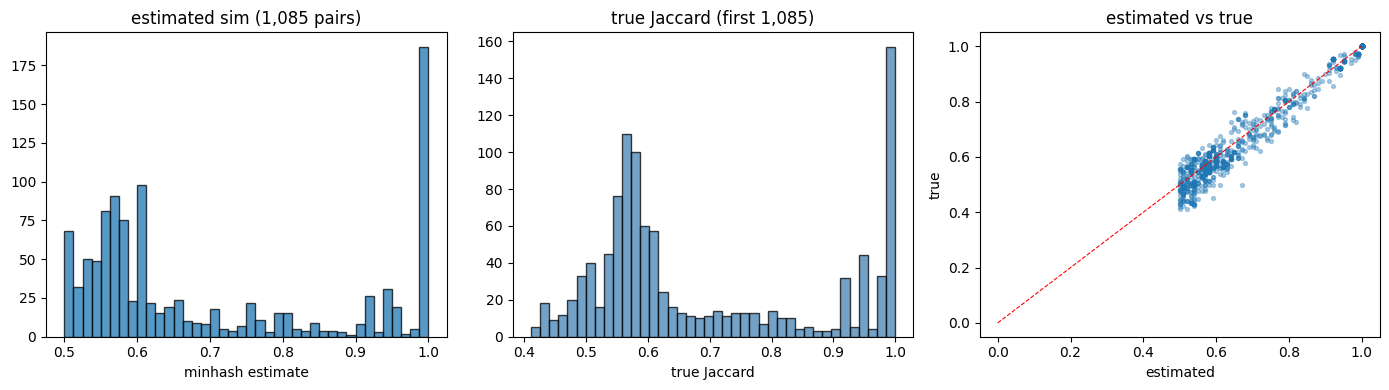

MAE: 0.0260


In [72]:
if similar_full:
    ests = [e for _, _, e in similar_full]
    sample = similar_full[:2_000]
    trues  = [jaccard(shingles_full[i], shingles_full[j]) for i, j, _ in sample]
    ests_s = [e for _, _, e in sample]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].hist(ests, bins=40, edgecolor='k', alpha=0.75)
    axes[0].set_title(f'estimated sim ({len(ests):,} pairs)')
    axes[0].set_xlabel('minhash estimate')

    axes[1].hist(trues, bins=40, edgecolor='k', alpha=0.75, color='steelblue')
    axes[1].set_title(f'true Jaccard (first {len(trues):,})')
    axes[1].set_xlabel('true Jaccard')

    axes[2].scatter(ests_s, trues, s=8, alpha=0.35)
    axes[2].plot([0, 1], [0, 1], 'r--', linewidth=0.8)
    axes[2].set_xlabel('estimated')
    axes[2].set_ylabel('true')
    axes[2].set_title('estimated vs true')

    plt.tight_layout()
    plt.show()

    mae = np.mean(np.abs(np.array(ests_s) - trues))
    print(f'MAE: {mae:.4f}')